# 🧬 Cancer Subtype Discovery  — Notebook 01: Exploratory Data Analysis (EDA)

**Project:** Pan-Cancer Subtype Discovery using Unsupervised ML  
**Dataset:** TCGA Pan-Cancer RNA-Seq (UCI ML Repository) — 801 patients, 20,531 genes  

## 📌 Objective
Understand the structure, quality, and distribution of gene expression data
before applying dimensionality reduction and clustering.

## 📋 Notebook Flow
1. Data Loading & Cleaning
2. Basic Information
3. Missing Values Check
4. Duplicate Check
5. Basic Statistics
6. Cancer Type Distribution
7. Feature Distribution & Skewness

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

BASE_DIR = Path.cwd().parent


In [2]:
# ── Data Loading & Cleaning ─────────────────────────────────────────
# Both CSV files contain an 'Unnamed: 0' column with sample IDs (sample_0, sample_1...)
# This column is not a feature — it's just a row identifier, so we drop it.
# From labels, we extract only the 'Class' column (cancer type) as our target variable y.

X = pd.read_csv(BASE_DIR / "data" / "raw" / 'data.csv')
labels = pd.read_csv(BASE_DIR / "data" / "raw" / 'labels.csv')

X = X.drop(columns=[X.columns[0]])   # Drop sample ID column (not a gene feature)
y = labels.iloc[:, 1]                 # Extract cancer type labels (BRCA, KIRC, COAD, LUAD, PRAD)

print("X shape:", X.shape)            # Expected: (801, 20531)
print("y shape:", y.shape)            # Expected: (801,)
print("Cancer types:", y.unique())    # Expected: 5 unique cancer types

X shape: (801, 20531)
y shape: (801,)
Cancer types: ['PRAD' 'LUAD' 'BRCA' 'KIRC' 'COAD']


In [3]:
# Basic information
print("=== BASIC INFO ===")
print(f"Total Patients: {X.shape[0]}")
print(f"Total Genes (Features): {X.shape[1]}")
print(f"\nData Types:\n{X.dtypes.value_counts()}")
print(f"\nFirst 5 rows:\n{X.iloc[:5, :5]}")  

=== BASIC INFO ===
Total Patients: 801
Total Genes (Features): 20531

Data Types:
float64    20531
Name: count, dtype: int64

First 5 rows:
   gene_0    gene_1    gene_2    gene_3     gene_4
0     0.0  2.017209  3.265527  5.478487  10.431999
1     0.0  0.592732  1.588421  7.586157   9.623011
2     0.0  3.511759  4.327199  6.881787   9.870730
3     0.0  3.663618  4.507649  6.659068  10.196184
4     0.0  2.655741  2.821547  6.539454   9.738265


In [4]:
print("=== MISSING VALUES ===")
print(f"Total Missing: {X.isnull().sum().sum()}")

=== MISSING VALUES ===
Total Missing: 0


In [7]:
print("===DUPLICATE VALUES ===")
print("Duplicate rows:", X.duplicated().sum())

===DUPLICATE VALUES ===
Duplicate rows: 0


In [6]:
print("=== BASIC STATISTICS ===")
print(X.describe().round(2))

=== BASIC STATISTICS ===
       gene_0  gene_1  gene_2  gene_3  gene_4  gene_5  gene_6  gene_7  gene_8  \
count  801.00  801.00  801.00  801.00  801.00   801.0  801.00  801.00  801.00   
mean     0.03    3.01    3.10    6.72    9.81     0.0    7.41    0.50    0.02   
std      0.14    1.20    1.07    0.64    0.51     0.0    1.11    0.51    0.13   
min      0.00    0.00    0.00    5.01    8.44     0.0    3.93    0.00    0.00   
25%      0.00    2.30    2.39    6.30    9.46     0.0    6.68    0.00    0.00   
50%      0.00    3.14    3.13    6.66    9.79     0.0    7.45    0.44    0.00   
75%      0.00    3.88    3.80    7.04   10.14     0.0    8.12    0.79    0.00   
max      1.48    6.24    6.06   10.13   11.36     0.0   10.72    2.78    1.79   

       gene_9  ...  gene_20521  gene_20522  gene_20523  gene_20524  \
count  801.00  ...      801.00      801.00      801.00      801.00   
mean     0.01  ...        5.90        8.77       10.06        4.85   
std      0.20  ...        0.75     

## 📊 Key Observations from Basic Statistics

- **Zero Variance Gene:** `gene_5` has mean=0, std=0, max=0 across all 801 patients.
  This gene carries no information and will be automatically eliminated during PCA.

- **Near-Zero Variance Genes:** `gene_0`, `gene_8`, `gene_9` have very low std (< 0.20),
  meaning almost no variation across patients — low utility for clustering.

- **High Variance Genes:** Genes like `gene_20524`, `gene_20529` have std > 2.0,
  meaning strong variation across patients — these will be most useful for clustering.

- **Value Range:** All gene expression values lie between 0 and ~13.
  This is consistent with log-normalized RNA-Seq data — no extreme outliers visible.

- **No Missing Values:** Dataset is completely clean (0 missing values).

- **All Features Float64:** No encoding or type conversion needed.

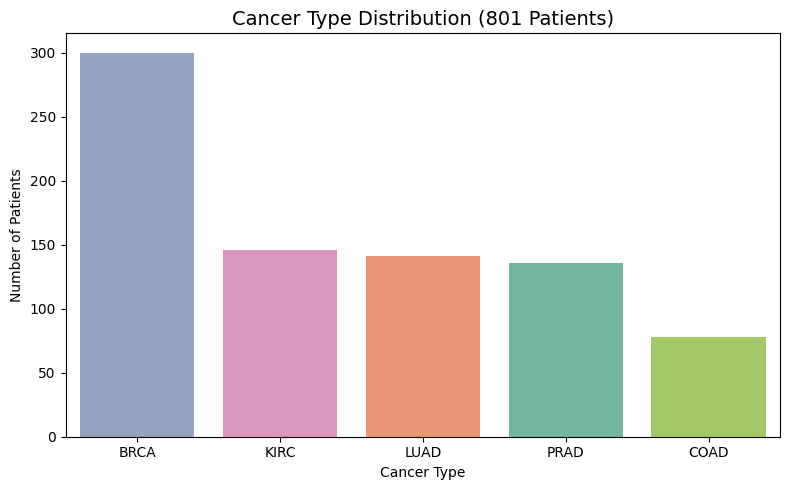

In [8]:
# === CANCER TYPE DISTRIBUTION ===
plt.figure(figsize=(8, 5))
sns.countplot(x=y, order=y.value_counts().index, 
              hue=y, palette='Set2', legend=False)
plt.title('Cancer Type Distribution (801 Patients)', fontsize=14)
plt.xlabel('Cancer Type')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.savefig('../images/cancer_distribution.png', dpi=150)
plt.show()

In [9]:
print("\nCancer Type Distribution:")
print(y.value_counts())
print(f"\nTotal Patients: {y.shape[0]}")


Cancer Type Distribution:
Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

Total Patients: 801


## 📊 Cancer Type Distribution Observations

- **BRCA** is the most frequent cancer type (~300 patients, ~37% of data).
- **COAD** is the least frequent (~80 patients) — may be harder to cluster.
- **KIRC, LUAD, PRAD** are relatively balanced (~136–147 patients each).
- Mild class imbalance exists, but since this is unsupervised learning,
  no class balancing technique is needed.

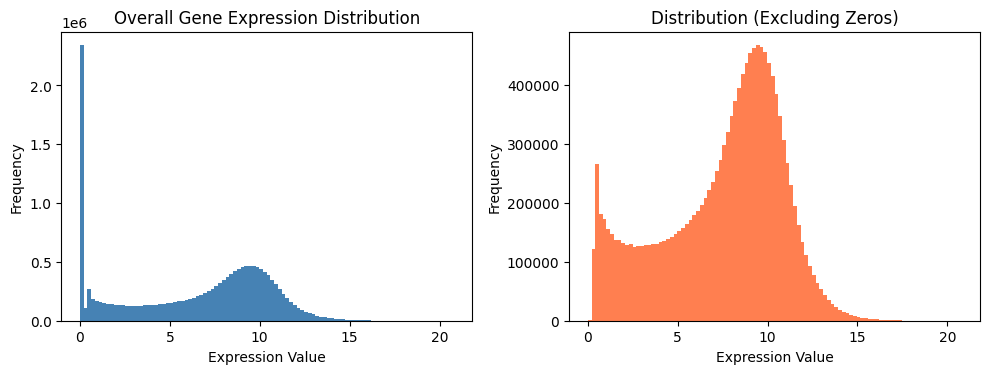

Overall Skewness: -0.3503


In [10]:
# === FEATURE DISTRIBUTION (Overall Gene Expression) ===
all_values = X.values.flatten()  # 801 x 20531 = ~16.4M values

plt.figure(figsize=(10, 4))

# Left plot — overall distribution
plt.subplot(1, 2, 1)
plt.hist(all_values, bins=100, color='steelblue', edgecolor='none')
plt.title('Overall Gene Expression Distribution')
plt.xlabel('Expression Value')
plt.ylabel('Frequency')

# Right plot — zoom in (0 to 15 range)
plt.subplot(1, 2, 2)
plt.hist(all_values[all_values > 0], bins=100, color='coral', edgecolor='none')
plt.title('Distribution (Excluding Zeros)')
plt.xlabel('Expression Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('../images/feature_distribution.png', dpi=150)
plt.show()

# Skewness
skewness = pd.Series(all_values).skew()
print(f"Overall Skewness: {skewness:.4f}")

## 📊 Feature Distribution Observations

- **Overall Skewness: -0.3503** — mildly left skewed.
- Data is already log-normalized (RNA-Seq standard preprocessing).
- Zero-inflated genes exist (many genes show 0 expression),
  but these will be handled automatically during PCA (low variance elimination).
- No scaling applied here — StandardScaler will be applied in Notebook 02 before PCA.